<div style="background-color: #111A33; padding: 28px; border-radius: 10px; text-align: center; color: white; margin-bottom: 25px; box-shadow: 0 4px 8px rgba(0,0,0,0.15);">
    <h1 style="margin: 0; font-size: 34px; font-weight: bold; color: #FFFFFF;">
        DebtStream Repayment and Recovery Insights (Fintech)
    </h1>
    <p style="margin: 12px 0 0 0; font-size: 19px; color: #F47B20; font-weight: bold;">
        Recovery Performance, Plan Sustainability and Priority Segments
    </p>
    <p style="margin: 8px 0 0 0; font-size: 15px; color: #D9E2EC;">
        Recovery Analytics | Repayment Behaviour | Affordability Impact | Client Portfolio Performance
    </p>
</div>

<h2 style="color: #0f172a; border-left: 5px solid #F47B20; padding-left: 12px; margin-top: 30px; font-weight: bold;">
Project Context & Objective
</h2>

In this notebook, I am analysing DebtStream's repayment and recovery outcomes across customer accounts, debt balance segments, debt age bands, client types, and affordability assessment behaviour.

The first notebook validated the data and explored the digital collections funnel. The second notebook tested whether supportive SMS messaging improved customer behaviour compared with a direct payment reminder.

This final notebook focuses on the commercial and operational question: **which segments recover better, which segments underperform, and where should DebtStream prioritise repayment journey improvements?**

The goal is to translate customer-level recovery data into practical recommendations for improving payment conversion, repayment plan sustainability, and client portfolio performance.

<h2 style="color: #0f172a; border-left: 5px solid #F47B20; padding-left: 12px; margin-top: 30px; font-weight: bold;">
The Analytical Pipeline
</h2>

This notebook follows a structured repayment and recovery analytics workflow:

**1. Load Recovery and Repayment Outputs**  
Load the SQL-exported recovery, plan sustainability, priority segment, and customer-level recovery files created during the BigQuery phase.

**2. Validate Overall Recovery Baseline**  
Calculate total outstanding balance, total amount collected, payment conversion rate, repayment plan setup rate, and overall recovery rate.

**3. Analyse Recovery by Balance Band**  
Compare recovery performance across Low, Medium, High, and Very High balance accounts.

**4. Analyse Recovery by Debt Age**  
Understand how recovery performance changes as debt gets older.

**5. Analyse Recovery by Client Type**  
Compare repayment and recovery outcomes across DebtStream's B2B client portfolio types.

**6. Evaluate Affordability Assessment Impact**  
Assess whether affordability completion is associated with stronger repayment plan sustainability.

**7. Identify Priority Recovery Segments**  
Highlight balance-band and debt-age combinations with weak recovery outcomes and higher support needs.

**8. Build Final Business Recommendations**  
Translate the analysis into a practical repayment optimisation strategy for DebtStream.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 1: Dataset Overview
</h2>

This notebook uses SQL-exported summary files created during the repayment and recovery phase in BigQuery.

| Dataset | Description |
|---|---|
| `recovery_by_balance_band.csv` | Recovery, payment, plan setup, and broken-plan performance by debt balance band |
| `recovery_by_debt_age.csv` | Recovery, payment, plan setup, and broken-plan performance by debt age band |
| `recovery_by_client_type.csv` | Recovery performance across DebtStream's B2B client portfolio types |
| `plan_sustainability_by_affordability.csv` | Repayment plan quality comparison by affordability assessment status |
| `recovery_priority_segments.csv` | Balance band × debt age segments ranked by weakest recovery performance |
| `customer_recovery_summary.csv` | Customer-level recovery dataset with payment flags, plan flags, amount collected, and customer recovery rate |

These files allow the notebook to focus on business interpretation, visual analysis, and recommendations rather than rebuilding all SQL joins here.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 2: Library Imports and Project Setup
</h2>

**Import Libraries and Configure Project Paths**

I am importing the Python libraries required for recovery analysis, data summarisation, and visualisation. I am also defining folder paths for loading SQL exported summary tables and saving charts or additional outputs.


In [1]:
# ============================================================
# Section 2: Library Imports and Project Setup
# ============================================================

# 1. Import core data analysis libraries
import pandas as pd
import numpy as np

# 2. Import visualisation library
import matplotlib.pyplot as plt

# 3. Import operating system library for file paths
import os

# 4. Set pandas display options for easier inspection
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 5. Set simple global chart formatting
#    Charts are intentionally kept clean and professional, without forcing brand colours.
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 6. Define project folder paths
#    This assumes the notebook is saved inside the /notebooks folder.
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
SUMMARY_TABLES_PATH = os.path.join(BASE_PATH, 'outputs', 'summary_tables')
CHARTS_PATH = os.path.join(BASE_PATH, 'outputs', 'charts')

# 7. Create output folders if they do not already exist
os.makedirs(CHARTS_PATH, exist_ok=True)
os.makedirs(SUMMARY_TABLES_PATH, exist_ok=True)

print("Libraries imported successfully.")
print("Project paths configured.")
print("Base path:", BASE_PATH)

Libraries imported successfully.
Project paths configured.
Base path: C:\Users\Utkarsh\DebtStream_Digital_Collections_Project


<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 3: Load Recovery and Repayment Data
</h2>

**Load SQL-Exported Recovery Outputs**

I am loading the SQL exported recovery and repayment summary tables created during the SQL phase.

The customer-level file `customer_recovery_summary.csv` is the main dataset for validating overall recovery metrics, while the segmented files support visual analysis by balance band, debt age, client type, affordability status, and priority recovery segments.

In [2]:
# ============================================================
# Section 3: Load Recovery and Repayment Data
# ============================================================

# 1. Load SQL exported recovery summary files
recovery_by_balance_band = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'recovery_by_balance_band.csv'))
recovery_by_debt_age = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'recovery_by_debt_age.csv'))
recovery_by_client_type = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'recovery_by_client_type.csv'))
plan_sustainability_by_affordability = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'plan_sustainability_by_affordability.csv'))
recovery_priority_segments = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'recovery_priority_segments.csv'))
customer_recovery_summary = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'customer_recovery_summary.csv'))

print("Recovery and repayment datasets loaded successfully.")

Recovery and repayment datasets loaded successfully.


In [3]:
# 2. Check the shape of each recovery dataset
recovery_dataset_shapes = pd.DataFrame({
    'dataset': [
        'recovery_by_balance_band',
        'recovery_by_debt_age',
        'recovery_by_client_type',
        'plan_sustainability_by_affordability',
        'recovery_priority_segments',
        'customer_recovery_summary'
    ],
    'rows': [
        recovery_by_balance_band.shape[0],
        recovery_by_debt_age.shape[0],
        recovery_by_client_type.shape[0],
        plan_sustainability_by_affordability.shape[0],
        recovery_priority_segments.shape[0],
        customer_recovery_summary.shape[0]
    ],
    'columns': [
        recovery_by_balance_band.shape[1],
        recovery_by_debt_age.shape[1],
        recovery_by_client_type.shape[1],
        plan_sustainability_by_affordability.shape[1],
        recovery_priority_segments.shape[1],
        customer_recovery_summary.shape[1]
    ]
})

recovery_dataset_shapes

,dataset,rows,columns
0,recovery_by_balance_band,4,10
1,recovery_by_debt_age,5,9
2,recovery_by_client_type,6,8
3,plan_sustainability_by_affordability,2,7
4,recovery_priority_segments,20,9
5,customer_recovery_summary,10000,24


In [4]:
# 3. Preview the customer-level recovery summary
customer_recovery_summary.head()

,customer_id,client_id,client_type,industry,integration_type,portfolio_type,debt_balance,balance_band,debt_age_days,debt_age_band,customer_age_band,region,vulnerability_flag,preferred_contact_channel,account_status,payment_made_flag,one_off_payment_flag,amount_collected,repayment_plan_created_flag,first_instalment_paid_flag,broken_plan_flag,affordability_completed_flag,max_missed_payment_count,customer_recovery_rate
0,DCUST000001,DSC006,Debt Collection Agency,Collections,Batch Upload,Early Arrears,340.19,Medium,90,31-90,18-24,East Midlands,0,SMS,No Engagement,0,0,0.00,0,0,0,0,0,0.00
1,DCUST000002,DSC001,Utility Provider,Utilities,API,Recoveries,"5,664.98",Very High,274,181-365,25-34,London,0,SMS,Open,0,0,0.00,0,0,0,0,0,0.00
2,DCUST000003,DSC002,Utility Provider,Utilities,Hybrid,Early Arrears,50.21,Low,31,31-90,55+,South East,0,SMS,Paid,1,1,43.03,0,0,0,0,0,0.86
3,DCUST000004,DSC001,Utility Provider,Utilities,API,Late Arrears,377.38,Medium,60,31-90,45-54,East Midlands,0,SMS,No Engagement,0,0,0.00,0,0,0,0,0,0.00
4,DCUST000005,DSC001,Utility Provider,Utilities,API,Late Arrears,135.04,Low,70,31-90,45-54,London,0,SMS,Paid,1,1,126.24,0,0,0,0,0,0.93


**Insight & Business Takeaway**

The recovery and repayment datasets loaded successfully. The segmented SQL outputs provide clean summary views for business analysis, while the customer-level recovery table contains 10,000 customer accounts and can be used to validate overall recovery metrics.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 4: Overall Recovery Baseline
</h2>

**Validate Overall Repayment and Recovery Performance**

Before analysing individual segments, I am calculating the overall recovery baseline from the customer-level recovery summary.

This baseline shows the total outstanding balance, total amount collected, payment conversion rate, repayment plan setup rate, broken-plan rate, and overall recovery rate across all customer accounts.

In [5]:
# ============================================================
# Section 4: Overall Recovery Baseline
# ============================================================

# 1. Calculate overall recovery baseline from customer-level data
total_customers = customer_recovery_summary['customer_id'].nunique()
total_outstanding_balance = customer_recovery_summary['debt_balance'].sum()
total_amount_collected = customer_recovery_summary['amount_collected'].sum()

overall_recovery_rate = total_amount_collected / total_outstanding_balance * 100

payment_customers = customer_recovery_summary[
    customer_recovery_summary['payment_made_flag'] == 1
]['customer_id'].nunique()

payment_conversion_rate = payment_customers / total_customers * 100

plan_customers = customer_recovery_summary[
    customer_recovery_summary['repayment_plan_created_flag'] == 1
]['customer_id'].nunique()

plan_setup_rate = plan_customers / total_customers * 100

broken_plan_customers = customer_recovery_summary[
    customer_recovery_summary['broken_plan_flag'] == 1
]['customer_id'].nunique()

broken_plan_rate_among_plans = broken_plan_customers / plan_customers * 100

# 2. Create overall recovery baseline table
overall_recovery_baseline = pd.DataFrame({
    'metric': [
        'Total Customer Accounts',
        'Total Outstanding Balance',
        'Total Amount Collected',
        'Overall Recovery Rate',
        'Customers with Successful Payment',
        'Payment Conversion Rate',
        'Customers with Repayment Plan',
        'Plan Setup Rate',
        'Broken Plan Customers',
        'Broken Plan Rate Among Plans'
    ],
    'value': [
        total_customers,
        total_outstanding_balance,
        total_amount_collected,
        overall_recovery_rate,
        payment_customers,
        payment_conversion_rate,
        plan_customers,
        plan_setup_rate,
        broken_plan_customers,
        broken_plan_rate_among_plans
    ]
})

overall_recovery_baseline

,metric,value
0,Total Customer Accounts,"10,000.00"
1,Total Outstanding Balance,"9,996,602.06"
2,Total Amount Collected,"330,918.42"
3,Overall Recovery Rate,3.31
4,Customers with Successful Payment,"1,136.00"
5,Payment Conversion Rate,11.36
6,Customers with Repayment Plan,743.00
7,Plan Setup Rate,7.43
8,Broken Plan Customers,301.00
9,Broken Plan Rate Among Plans,40.51


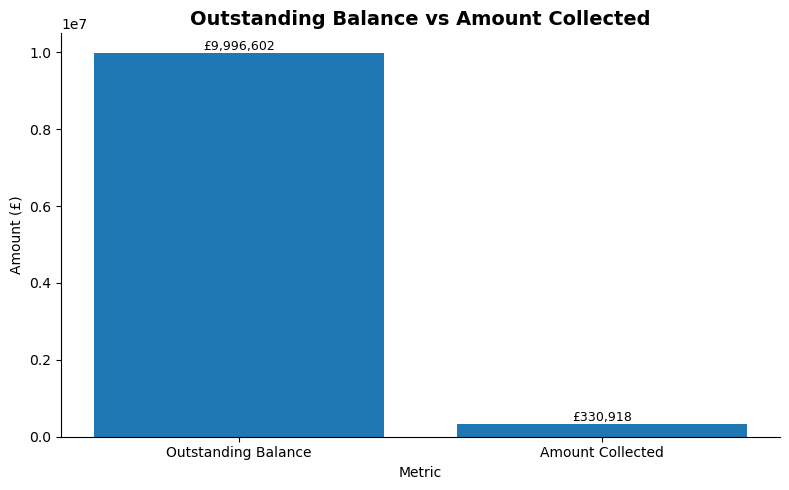

In [6]:
# 3. Create a simple commercial baseline chart
commercial_baseline = pd.DataFrame({
    'metric': [
        'Outstanding Balance',
        'Amount Collected'
    ],
    'amount': [
        total_outstanding_balance,
        total_amount_collected
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    commercial_baseline['metric'],
    commercial_baseline['amount']
)

ax.set_title('Outstanding Balance vs Amount Collected', fontsize=14, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Amount (£)')

# 4. Add value labels
for index, value in enumerate(commercial_baseline['amount']):
    ax.text(index, value, f'£{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'recovery_outstanding_vs_collected.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The overall recovery baseline shows that DebtStream processed 10,000 customer accounts with just under £10 million in outstanding balance. Around £331K was collected through successful payments, producing an overall recovery rate of approximately 3.31%.

The payment conversion rate is around 11.36%, while 7.43% of customers created repayment plans. Among customers who created repayment plans, around 40.51% had broken plans, which shows that plan setup alone is not enough. Plan sustainability also needs to be monitored.

**Indication:** DebtStream should evaluate recovery performance using both payment conversion and repayment plan quality. A high plan setup rate is useful only if plans remain sustainable and lead to actual repayment behaviour.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 5: Recovery Performance by Balance Band
</h2>

**Compare Recovery Outcomes Across Debt Balance Bands**

I am analysing recovery performance across Low, Medium, High, and Very High balance accounts.

This section helps understand whether smaller balances are easier to recover through digital self-service, and whether higher-balance customers require more supportive repayment journeys or affordability-led interventions.

The key metrics are recovery rate, payment conversion rate, repayment plan setup rate, and broken-plan rate.

In [9]:
# ============================================================
# Section 5: Recovery Performance by Balance Band
# ============================================================

# 1. Apply business order to balance bands
balance_order = ['Low', 'Medium', 'High', 'Very High']

recovery_balance = recovery_by_balance_band.copy()

recovery_balance['balance_band'] = pd.Categorical(
    recovery_balance['balance_band'],
    categories=balance_order,
    ordered=True
)

recovery_balance = recovery_balance.sort_values('balance_band')

# 2. Display ordered recovery performance by balance band
recovery_balance

,balance_band,total_customers,avg_debt_balance,total_outstanding_balance,total_amount_collected,recovery_rate,payment_conversion_rate,one_off_payment_rate,plan_setup_rate,broken_plan_rate
0,Low,3508,148.15,"519,708.92","54,950.01",10.57,13.23,9.92,4.76,41.32
1,Medium,4065,627.21,"2,549,618.24","127,446.13",5.00,11.22,3.32,10.06,35.70
2,High,1853,"2,015.65","3,735,003.98","120,160.07",3.22,10.04,3.83,8.04,48.99
3,Very High,574,"5,561.45","3,192,270.92","28,362.21",0.89,5.23,3.14,3.14,72.22


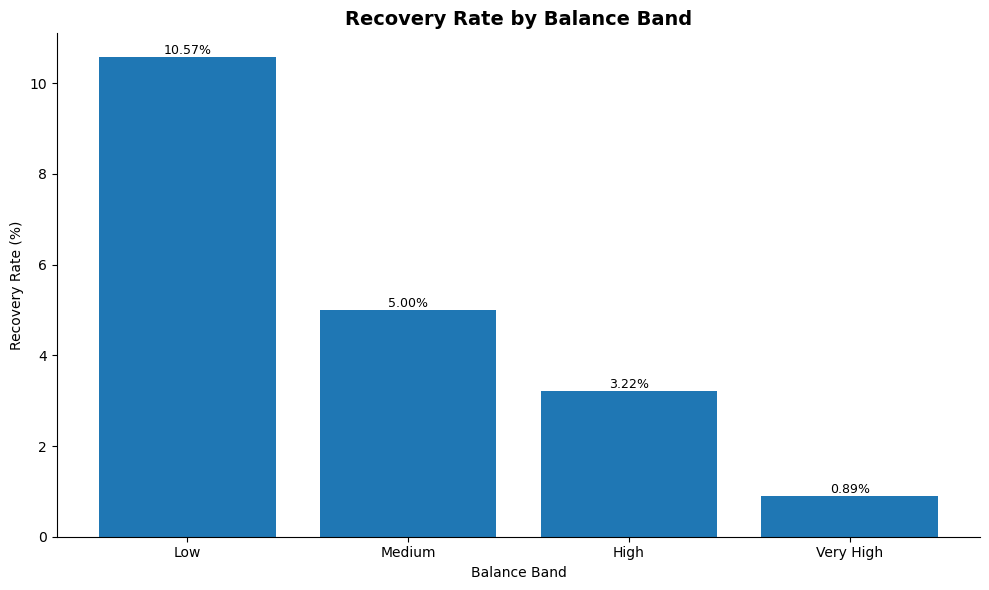

In [10]:
# 3. Plot recovery rate by balance band
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    recovery_balance['balance_band'].astype(str),
    recovery_balance['recovery_rate']
)

ax.set_title('Recovery Rate by Balance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Recovery Rate (%)')

# 4. Add percentage labels
for index, value in enumerate(recovery_balance['recovery_rate']):
    ax.text(index, value, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'recovery_rate_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

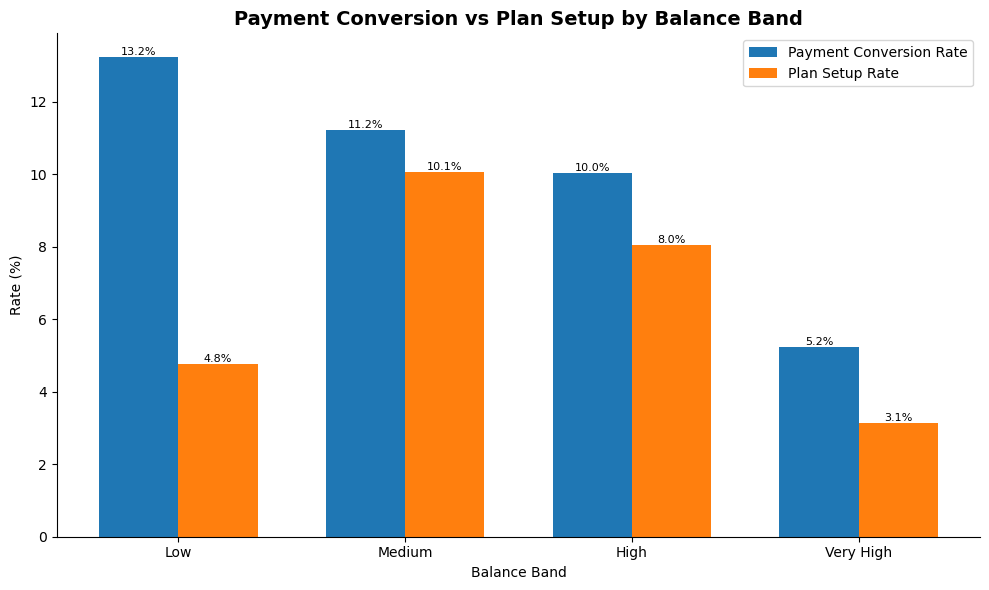

In [11]:
# 5. Create grouped bar chart for payment conversion and plan setup by balance band
x = np.arange(len(recovery_balance['balance_band']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    recovery_balance['payment_conversion_rate'],
    width,
    label='Payment Conversion Rate'
)

ax.bar(
    x + width / 2,
    recovery_balance['plan_setup_rate'],
    width,
    label='Plan Setup Rate'
)

ax.set_title('Payment Conversion vs Plan Setup by Balance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(recovery_balance['balance_band'].astype(str))
ax.legend()

# 6. Add value labels
for index, value in enumerate(recovery_balance['payment_conversion_rate']):
    ax.text(index - width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

for index, value in enumerate(recovery_balance['plan_setup_rate']):
    ax.text(index + width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'payment_vs_plan_setup_by_balance_band_recovery.png'), dpi=300, bbox_inches='tight')
plt.show()

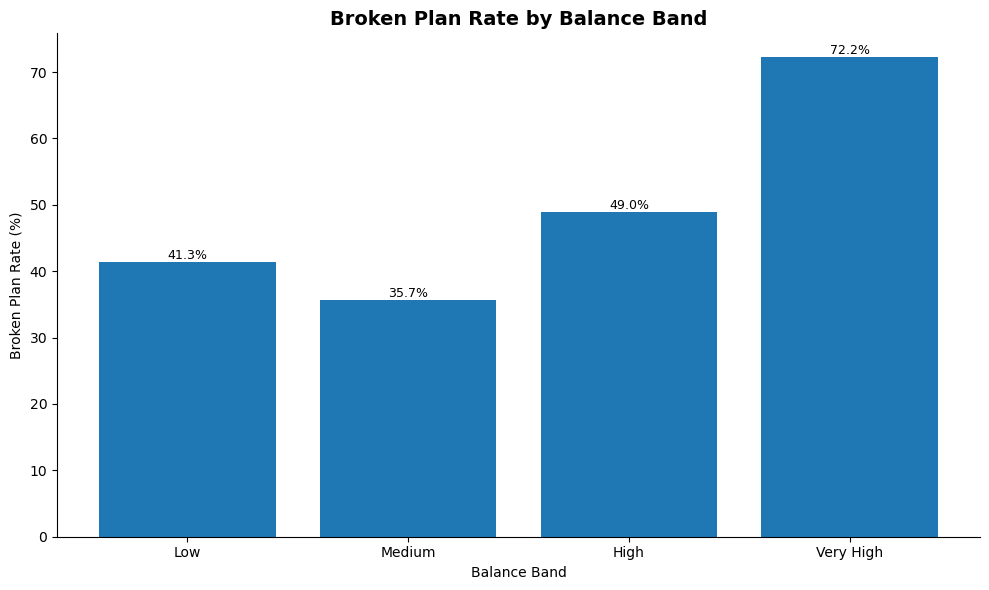

In [12]:
# 7. Plot broken-plan rate by balance band
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    recovery_balance['balance_band'].astype(str),
    recovery_balance['broken_plan_rate']
)

ax.set_title('Broken Plan Rate by Balance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Broken Plan Rate (%)')

# 8. Add percentage labels
for index, value in enumerate(recovery_balance['broken_plan_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'broken_plan_rate_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Recovery performance differs strongly by balance band. Low-balance accounts show the highest recovery rate, which suggests that smaller balances are easier for customers to resolve through digital self-service.

Medium-balance accounts show the strongest repayment plan setup behaviour, making them a strong candidate for flexible repayment messaging and repayment-plan nudges.

Very High-balance accounts have the weakest recovery rate and the highest broken-plan rate. This suggests that standard digital self-service journeys may not be enough for these customers, especially where affordability pressure is higher.

**Indication:** DebtStream should treat balance band as a core segmentation variable. Low balances can be prioritised for direct payment journeys, Medium balances for repayment-plan journeys, and High or Very High balances for affordability-led support.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 6: Recovery Performance by Debt Age Band
</h2>

**Analyse How Recovery Changes as Debt Gets Older**

I am analysing recovery performance across debt age bands to understand how the age of an account affects customer repayment behaviour.

Debt age is important because newer debts are usually more responsive to digital repayment prompts, while older debts often require more intensive support, different messaging, or alternative collections strategies.

In [15]:
# ============================================================
# Section 6: Recovery Performance by Debt Age Band
# ============================================================

# 1. Apply business order to debt age bands
debt_age_order = ['0-30', '31-90', '91-180', '181-365', '365+']

recovery_debt_age = recovery_by_debt_age.copy()

recovery_debt_age['debt_age_band'] = pd.Categorical(
    recovery_debt_age['debt_age_band'],
    categories=debt_age_order,
    ordered=True
)

recovery_debt_age = recovery_debt_age.sort_values('debt_age_band')

recovery_debt_age

,debt_age_band,total_customers,avg_debt_age_days,total_outstanding_balance,total_amount_collected,recovery_rate,payment_conversion_rate,plan_setup_rate,broken_plan_rate
0,0-30,1539,15.04,"966,981.59","59,021.64",6.10,18.00,10.27,37.34
1,31-90,2123,60.97,"1,569,754.83","76,975.36",4.90,14.13,9.14,36.08
2,91-180,2842,135.63,"2,984,044.49","91,923.76",3.08,9.64,6.65,40.74
3,181-365,2224,272.83,"2,771,418.52","77,746.82",2.81,9.40,6.65,44.59
4,365+,1272,630.24,"1,704,402.63","25,250.84",1.48,5.97,4.25,53.70


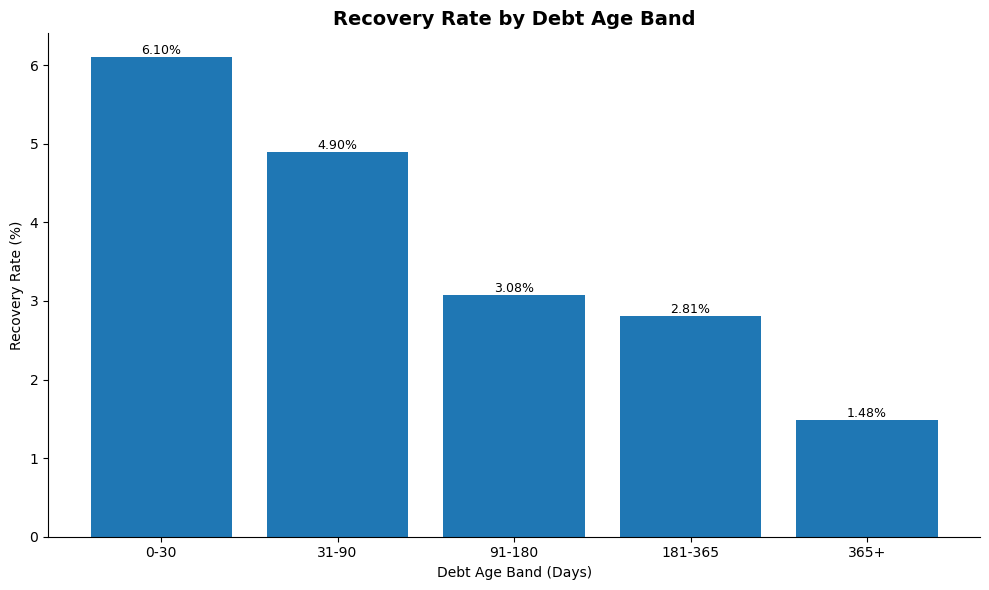

In [20]:
# 2. Plot recovery rate by debt age band
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    recovery_debt_age['debt_age_band'].astype(str),
    recovery_debt_age['recovery_rate']
)

ax.set_title('Recovery Rate by Debt Age Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Age Band (Days)')
ax.set_ylabel('Recovery Rate (%)')

# 3. Add percentage labels
for index, value in enumerate(recovery_debt_age['recovery_rate']):
    ax.text(index, value, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'recovery_rate_by_debt_age_band.png'), dpi=300, bbox_inches='tight')
plt.show()

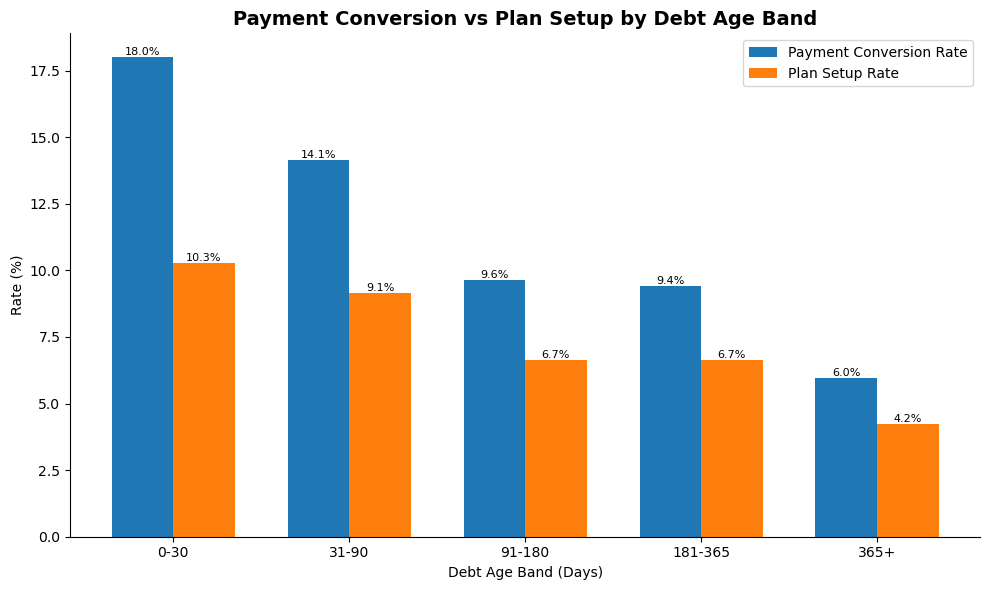

In [21]:
# 4. Create grouped bar chart for payment conversion and plan setup by debt age band
x = np.arange(len(recovery_debt_age['debt_age_band']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    recovery_debt_age['payment_conversion_rate'],
    width,
    label='Payment Conversion Rate'
)

ax.bar(
    x + width / 2,
    recovery_debt_age['plan_setup_rate'],
    width,
    label='Plan Setup Rate'
)

ax.set_title('Payment Conversion vs Plan Setup by Debt Age Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Age Band (Days)')
ax.set_ylabel('Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(recovery_debt_age['debt_age_band'].astype(str))
ax.legend()

# 5. Add value labels
for index, value in enumerate(recovery_debt_age['payment_conversion_rate']):
    ax.text(index - width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

for index, value in enumerate(recovery_debt_age['plan_setup_rate']):
    ax.text(index + width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'payment_vs_plan_setup_by_debt_age_band.png'), dpi=300, bbox_inches='tight')
plt.show()

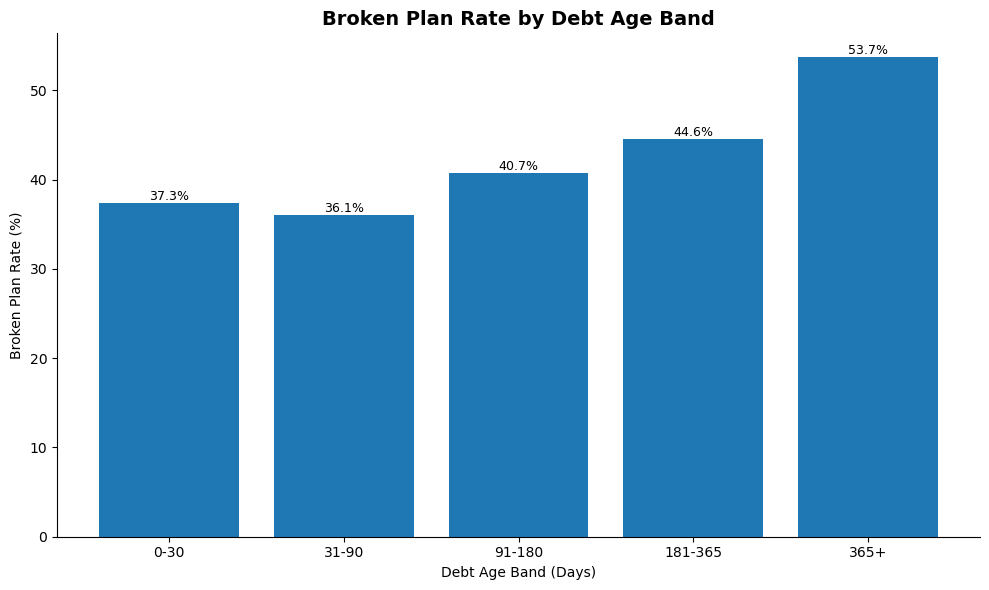

In [22]:
# 6. Plot broken-plan rate by debt age band
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    recovery_debt_age['debt_age_band'].astype(str),
    recovery_debt_age['broken_plan_rate']
)

ax.set_title('Broken Plan Rate by Debt Age Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Age Band (Days)')
ax.set_ylabel('Broken Plan Rate (%)')

# 7. Add percentage labels
for index, value in enumerate(recovery_debt_age['broken_plan_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'broken_plan_rate_by_debt_age_band.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Recovery performance declines as debt gets older. Newer accounts show stronger recovery rates and higher payment conversion, while older accounts, especially those over 365 days, show weaker repayment outcomes.

This pattern is commercially important because early intervention appears to produce stronger digital collections performance. As debts age, customers may become harder to re-engage and may require more supportive or alternative treatment strategies.

Broken-plan rates also increase across older debt bands, which suggests that older debt customers may not only be harder to convert, but also harder to retain in sustainable repayment plans.

**Indication:** DebtStream should prioritise early digital engagement and treat debt age as a key risk indicator for recovery strategy, message tone, and repayment plan monitoring.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 7: Recovery Performance by Client Type
</h2>

**Compare Recovery Outcomes Across B2B Client Portfolios**

I am analysing recovery performance by client type to understand how DebtStream's digital collections outcomes differ across its B2B portfolio.

This is important because customer repayment behaviour can vary depending on whether the account comes from a consumer lender, utility provider, telecoms company, debt purchaser, debt collection agency, or legal collections portfolio.

In [23]:
# ============================================================
# Section 7: Recovery Performance by Client Type
# ============================================================

# 1. Sort client types by recovery rate
recovery_client = recovery_by_client_type.copy()

recovery_client = recovery_client.sort_values('recovery_rate', ascending=False)

recovery_client

,client_type,total_customers,total_outstanding_balance,total_amount_collected,recovery_rate,payment_conversion_rate,plan_setup_rate,broken_plan_rate
0,Telecoms,781,"537,453.60","32,266.62",6.00,14.08,9.09,35.21
1,Consumer Lender,2426,"2,351,167.18","101,192.96",4.30,14.34,8.53,40.10
2,Utility Provider,3494,"3,483,258.27","114,680.79",3.29,11.71,8.24,40.97
3,Debt Collection Agency,2003,"2,048,740.42","62,040.86",3.03,10.23,6.74,38.52
4,Debt Purchaser,933,"1,053,511.42","16,325.00",1.55,4.93,2.79,46.15
5,Legal Collections,363,"522,471.17","4,412.19",0.84,4.96,4.41,68.75


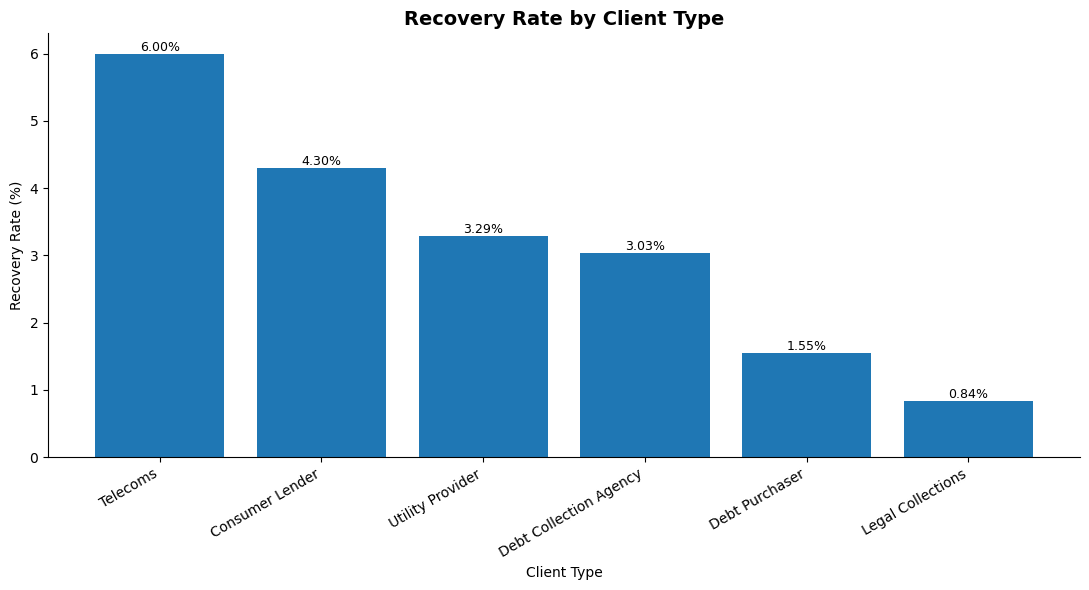

In [24]:
# 2. Plot recovery rate by client type
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    recovery_client['client_type'],
    recovery_client['recovery_rate']
)

ax.set_title('Recovery Rate by Client Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Client Type')
ax.set_ylabel('Recovery Rate (%)')

plt.xticks(rotation=30, ha='right')

# 3. Add percentage labels
for index, value in enumerate(recovery_client['recovery_rate']):
    ax.text(index, value, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'recovery_rate_by_client_type.png'), dpi=300, bbox_inches='tight')
plt.show()

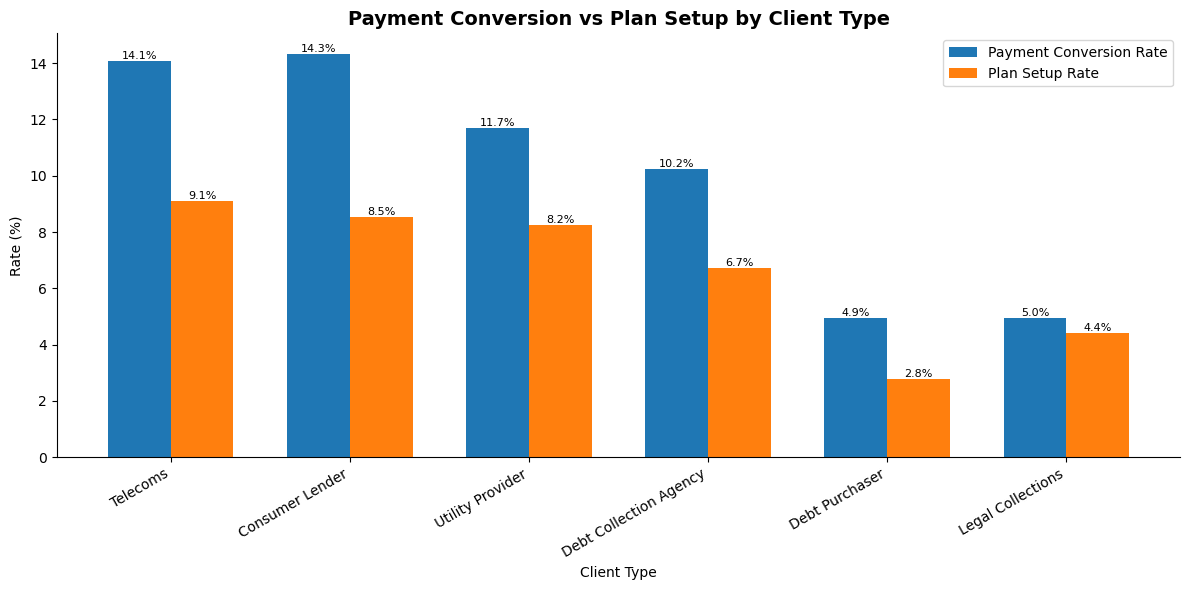

In [25]:
# 4. Plot payment conversion and plan setup by client type
x = np.arange(len(recovery_client['client_type']))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width / 2,
    recovery_client['payment_conversion_rate'],
    width,
    label='Payment Conversion Rate'
)

ax.bar(
    x + width / 2,
    recovery_client['plan_setup_rate'],
    width,
    label='Plan Setup Rate'
)

ax.set_title('Payment Conversion vs Plan Setup by Client Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Client Type')
ax.set_ylabel('Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(recovery_client['client_type'], rotation=30, ha='right')
ax.legend()

# 5. Add value labels
for index, value in enumerate(recovery_client['payment_conversion_rate']):
    ax.text(index - width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

for index, value in enumerate(recovery_client['plan_setup_rate']):
    ax.text(index + width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'payment_vs_plan_setup_by_client_type.png'), dpi=300, bbox_inches='tight')
plt.show()

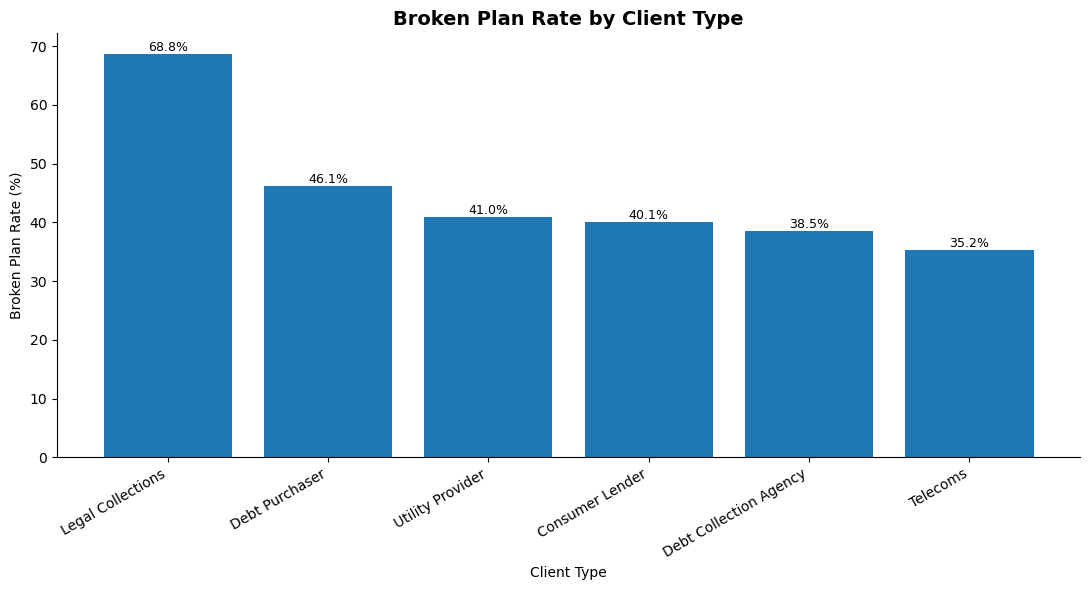

In [26]:
# 6. Plot broken-plan rate by client type
fig, ax = plt.subplots(figsize=(11, 6))

broken_client = recovery_client.sort_values('broken_plan_rate', ascending=False)

ax.bar(
    broken_client['client_type'],
    broken_client['broken_plan_rate']
)

ax.set_title('Broken Plan Rate by Client Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Client Type')
ax.set_ylabel('Broken Plan Rate (%)')

plt.xticks(rotation=30, ha='right')

# 7. Add percentage labels
for index, value in enumerate(broken_client['broken_plan_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'broken_plan_rate_by_client_type.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Recovery performance varies meaningfully by client type. Telecoms and Consumer Lender portfolios show stronger recovery outcomes, while Debt Purchaser and Legal Collections portfolios show weaker recovery rates.

This difference is commercially important because client type reflects different portfolio characteristics, customer behaviours, debt profiles, and urgency levels. A single benchmark across all client types may hide important portfolio-level differences.

Legal Collections and Debt Purchaser portfolios should be interpreted carefully because they often contain more complex, older, or harder-to-recover accounts.

**Indication:** DebtStream should benchmark recovery performance by client type rather than relying only on the overall recovery average. Client-specific reporting can help identify which portfolios need additional support, affordability journeys, or escalation strategies.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 8: Affordability Assessment Impact
</h2>

**Compare Repayment Plan Sustainability by Affordability Status**

I am analysing whether customers who completed an affordability assessment showed stronger repayment plan outcomes than customers who did not.

This is important because repayment plan setup alone does not guarantee successful recovery. A customer may create a plan but later miss payments or break the plan. Affordability assessment can help ensure that repayment plans are realistic and sustainable.

In [27]:
# ============================================================
# Section 8: Affordability Assessment Impact
# ============================================================

# 1. Prepare affordability impact table
affordability_impact = plan_sustainability_by_affordability.copy()

# 2. Display affordability impact summary
affordability_impact

,affordability_status,total_repayment_plans,first_instalment_paid_rate,broken_plan_rate,avg_missed_payment_count,avg_plan_amount,avg_instalment_amount
0,Affordability Completed,203,86.21,31.53,1.01,829.93,127.50
1,No Affordability Completed,540,75.19,43.89,1.16,665.38,111.20


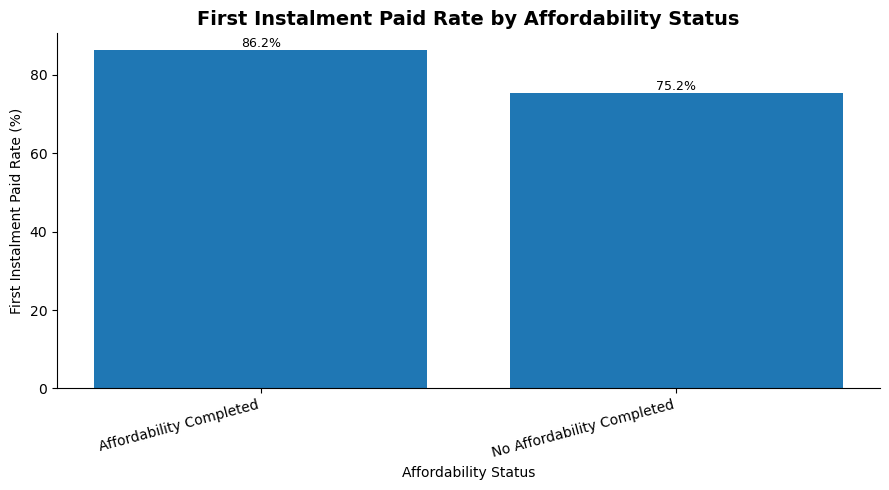

In [28]:
# 3. Plot first instalment paid rate by affordability status
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    affordability_impact['affordability_status'],
    affordability_impact['first_instalment_paid_rate']
)

ax.set_title('First Instalment Paid Rate by Affordability Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Affordability Status')
ax.set_ylabel('First Instalment Paid Rate (%)')

plt.xticks(rotation=15, ha='right')

# 4. Add percentage labels
for index, value in enumerate(affordability_impact['first_instalment_paid_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'first_instalment_paid_rate_by_affordability.png'), dpi=300, bbox_inches='tight')
plt.show()

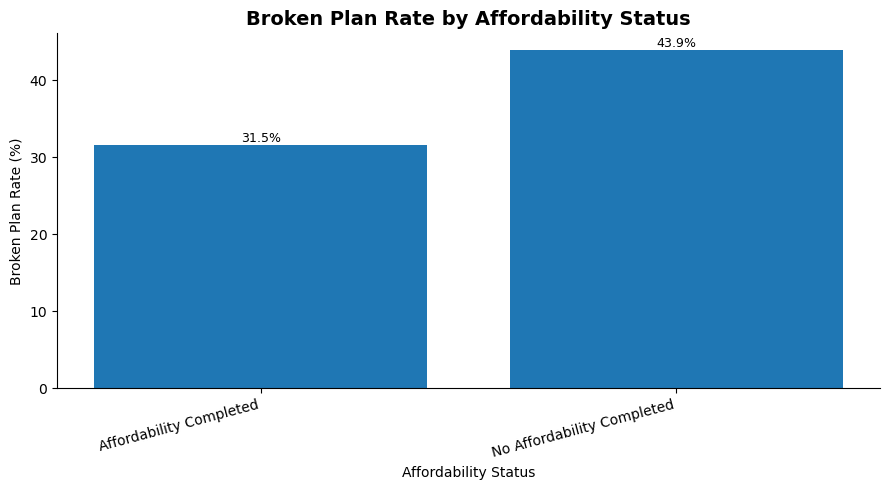

In [29]:
# 5. Plot broken-plan rate by affordability status
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    affordability_impact['affordability_status'],
    affordability_impact['broken_plan_rate']
)

ax.set_title('Broken Plan Rate by Affordability Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Affordability Status')
ax.set_ylabel('Broken Plan Rate (%)')

plt.xticks(rotation=15, ha='right')

# 6. Add percentage labels
for index, value in enumerate(affordability_impact['broken_plan_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'broken_plan_rate_by_affordability.png'), dpi=300, bbox_inches='tight')
plt.show()

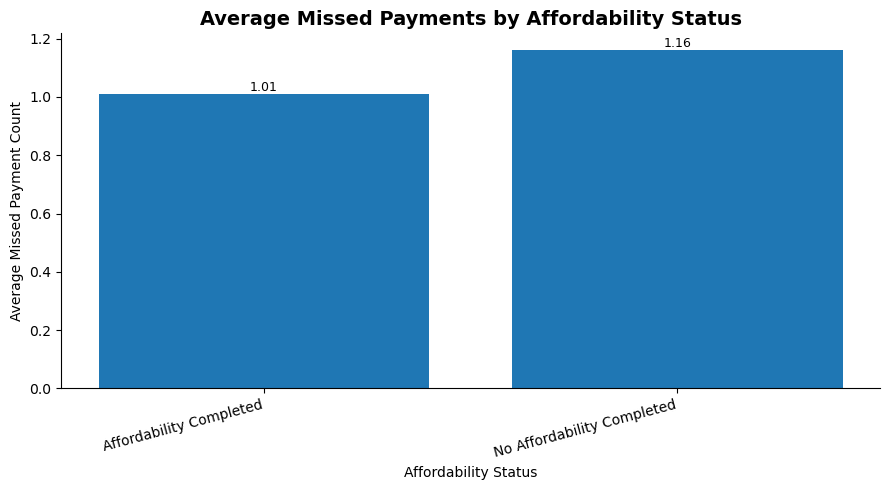

In [30]:
# 7. Plot average missed payment count by affordability status
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    affordability_impact['affordability_status'],
    affordability_impact['avg_missed_payment_count']
)

ax.set_title('Average Missed Payments by Affordability Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Affordability Status')
ax.set_ylabel('Average Missed Payment Count')

plt.xticks(rotation=15, ha='right')

# 8. Add value labels
for index, value in enumerate(affordability_impact['avg_missed_payment_count']):
    ax.text(index, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'avg_missed_payments_by_affordability.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Customers who completed an affordability assessment show stronger repayment plan sustainability. They have a higher first instalment paid rate and a lower broken-plan rate compared with customers who did not complete affordability assessment.

This suggests that affordability assessment is not only a compliance or customer-support step. It also has commercial value because it helps customers create repayment plans that are more realistic and easier to sustain.

**Indication:** DebtStream should encourage affordability assessment completion, especially for customers with higher balances or customers entering repayment plans. Plan setup should be measured alongside plan sustainability, not treated as the final success metric.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 9: Recovery Priority Segments
</h2>

**Identify Segments with Weak Recovery Performance**

I am analysing recovery priority segments by combining balance band and debt age band.

This helps identify the customer groups where recovery is weakest and where DebtStream may need stronger intervention, better repayment-plan support, affordability-led journeys, or different communication strategies.

In [31]:
# ============================================================
# Section 9: Recovery Priority Segments
# ============================================================

# 1. Prepare recovery priority segments
priority_segments = recovery_priority_segments.copy()

# 2. Apply business order to balance and debt age bands
balance_order = ['Low', 'Medium', 'High', 'Very High']
debt_age_order = ['0-30', '31-90', '91-180', '181-365', '365+']

priority_segments['balance_band'] = pd.Categorical(
    priority_segments['balance_band'],
    categories=balance_order,
    ordered=True
)

priority_segments['debt_age_band'] = pd.Categorical(
    priority_segments['debt_age_band'],
    categories=debt_age_order,
    ordered=True
)

# 3. Display weakest recovery segments first
priority_segments_sorted = priority_segments.sort_values('recovery_rate', ascending=True)

priority_segments_sorted.head(10)

,balance_band,debt_age_band,total_customers,total_outstanding_balance,total_amount_collected,recovery_rate,payment_conversion_rate,plan_setup_rate,broken_plan_rate
0,Very High,365+,122,"682,843.71","4,763.69",0.70,3.28,2.46,66.67
1,Very High,91-180,166,"906,339.41","7,314.86",0.81,6.02,4.82,75.00
2,Very High,31-90,64,"351,203.96","2,906.10",0.83,6.25,3.13,100.00
3,Very High,181-365,184,"1,042,260.74","10,635.30",1.02,4.35,2.17,50.00
4,Very High,0-30,38,"209,623.10","2,742.26",1.31,10.53,2.63,100.00
5,High,365+,303,"617,653.11","9,026.41",1.46,5.61,4.95,86.67
6,Medium,365+,549,"357,972.31","7,748.70",2.16,4.92,5.10,32.14
7,High,0-30,143,"285,494.00","8,069.16",2.83,12.59,9.09,61.54
8,High,181-365,535,"1,087,594.45","31,472.18",2.89,7.85,6.92,43.24
9,High,91-180,595,"1,205,166.39","45,961.66",3.81,11.09,8.07,41.67


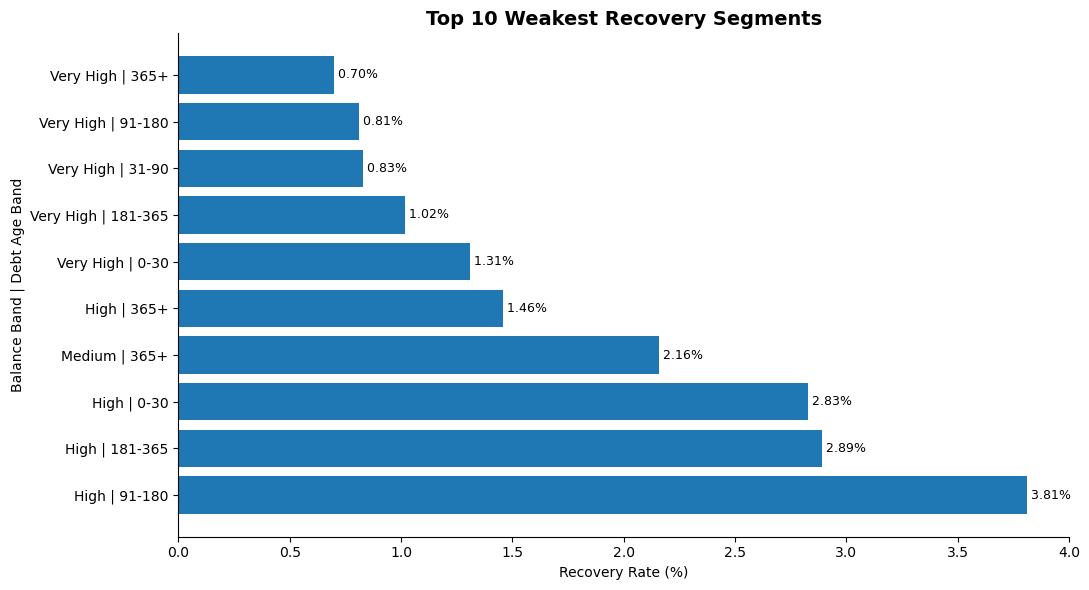

In [32]:
# 4. Prepare top 10 weakest segments for charting
weakest_segments = priority_segments_sorted.head(10).copy()

weakest_segments['segment'] = (
    weakest_segments['balance_band'].astype(str) + ' | ' + weakest_segments['debt_age_band'].astype(str)
)

# 5. Plot weakest recovery segments
fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    weakest_segments['segment'],
    weakest_segments['recovery_rate']
)

ax.set_title('Top 10 Weakest Recovery Segments', fontsize=14, fontweight='bold')
ax.set_xlabel('Recovery Rate (%)')
ax.set_ylabel('Balance Band | Debt Age Band')

# 6. Add percentage labels
for index, value in enumerate(weakest_segments['recovery_rate']):
    ax.text(value, index, f' {value:.2f}%', va='center', fontsize=9)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'top_10_weakest_recovery_segments.png'), dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# 7. Create recovery rate matrix for balance band and debt age band
recovery_matrix = priority_segments.pivot(
    index='balance_band',
    columns='debt_age_band',
    values='recovery_rate'
)

recovery_matrix

debt_age_band,0-30,31-90,91-180,181-365,365+
balance_band,,,,,
Low,14.88,12.66,7.09,8.50,8.08
Medium,8.70,5.80,3.94,5.06,2.16
High,2.83,4.75,3.81,2.89,1.46
Very High,1.31,0.83,0.81,1.02,0.70


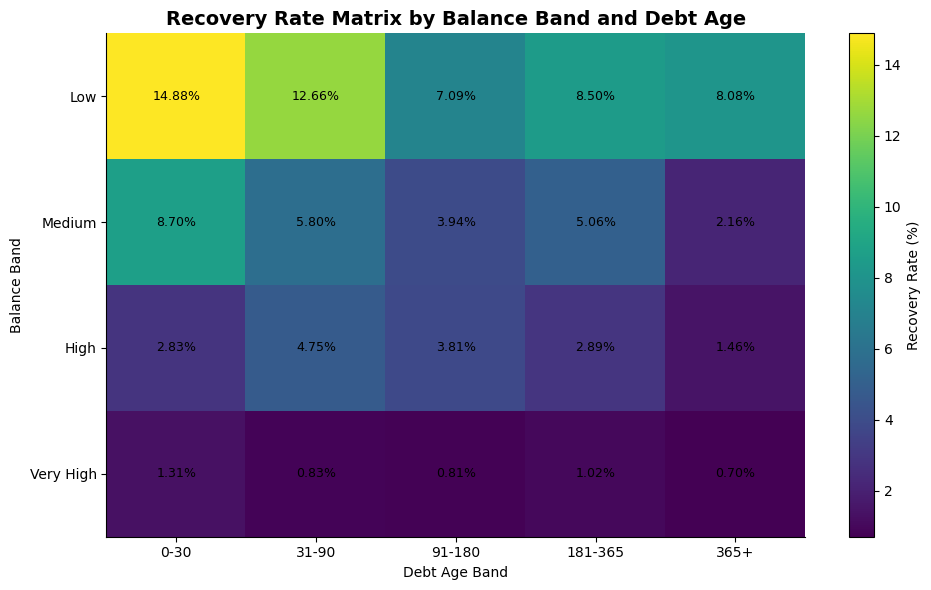

In [34]:
# 8. Plot recovery rate matrix as a heatmap-style chart
fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(recovery_matrix, aspect='auto')

ax.set_title('Recovery Rate Matrix by Balance Band and Debt Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Age Band')
ax.set_ylabel('Balance Band')

ax.set_xticks(np.arange(len(recovery_matrix.columns)))
ax.set_yticks(np.arange(len(recovery_matrix.index)))

ax.set_xticklabels(recovery_matrix.columns)
ax.set_yticklabels(recovery_matrix.index)

# 9. Add recovery rate labels inside cells
for i in range(len(recovery_matrix.index)):
    for j in range(len(recovery_matrix.columns)):
        value = recovery_matrix.iloc[i, j]
        ax.text(j, i, f'{value:.2f}%', ha='center', va='center', fontsize=9)

plt.colorbar(image, ax=ax, label='Recovery Rate (%)')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'recovery_rate_matrix_balance_debt_age.png'), dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# 10. Identify segments with high outstanding balance and weak recovery
outstanding_threshold = priority_segments['total_outstanding_balance'].median()
recovery_threshold = priority_segments['recovery_rate'].median()

high_exposure_low_recovery = priority_segments[
    (priority_segments['total_outstanding_balance'] >= outstanding_threshold) &
    (priority_segments['recovery_rate'] <= recovery_threshold)
].copy()

high_exposure_low_recovery = high_exposure_low_recovery.sort_values(
    ['total_outstanding_balance', 'recovery_rate'],
    ascending=[False, True]
)

high_exposure_low_recovery

,balance_band,debt_age_band,total_customers,total_outstanding_balance,total_amount_collected,recovery_rate,payment_conversion_rate,plan_setup_rate,broken_plan_rate
9,High,91-180,595,"1,205,166.39","45,961.66",3.81,11.09,8.07,41.67
8,High,181-365,535,"1,087,594.45","31,472.18",2.89,7.85,6.92,43.24
3,Very High,181-365,184,"1,042,260.74","10,635.30",1.02,4.35,2.17,50.00
1,Very High,91-180,166,"906,339.41","7,314.86",0.81,6.02,4.82,75.00
0,Very High,365+,122,"682,843.71","4,763.69",0.70,3.28,2.46,66.67
5,High,365+,303,"617,653.11","9,026.41",1.46,5.61,4.95,86.67


**Insight & Business Takeaway**

The weakest recovery segments are concentrated among higher-balance and older-debt accounts. Very High balance accounts, especially those with older debt age bands, show particularly weak recovery performance.

This does not mean these customers should be ignored. It means they may need a different journey from lower-balance or newer-debt customers. Standard digital reminders may not be enough where the balance is large, the debt is old, or the repayment burden is harder to manage.

The high-exposure, low-recovery view is especially useful because it highlights where commercial risk is concentrated. These are the segments where DebtStream may need stronger affordability journeys, additional support prompts, or prioritised client reporting.

**Indication:** Recovery strategy should combine both recovery rate and outstanding balance exposure. The priority should not only be the weakest conversion segment, but the weakest segment with meaningful commercial exposure.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 10: Customer-Level Recovery Exploration
</h2>

**Explore Customer-Level Recovery Patterns**

I am now using the customer-level recovery summary to explore the distribution of debt balance, amount collected, and customer recovery rate.

This section helps validate the segment-level findings and gives a clearer view of how repayment behaviour is distributed across individual customer accounts.

In [36]:
# ============================================================
# Section 10: Customer-Level Recovery Exploration
# ============================================================

# 1. Review customer-level recovery summary statistics
customer_recovery_summary[
    [
        'debt_balance',
        'amount_collected',
        'customer_recovery_rate'
    ]
].describe()

,debt_balance,amount_collected,customer_recovery_rate
count,"10,000.00","10,000.00","10,000.00"
mean,999.66,33.09,0.06
std,"1,377.95",141.98,0.20
min,50.07,0.00,0.00
25%,189.63,0.00,0.00
50%,525.11,0.00,0.00
75%,984.86,0.00,0.00
max,"7,999.52","3,951.86",1.07


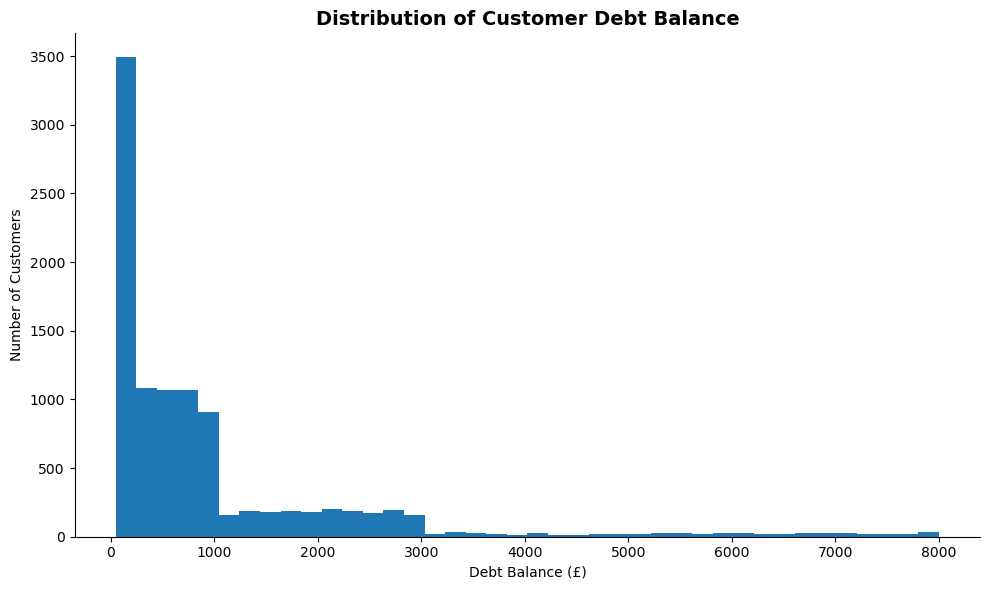

In [37]:
# 2. Plot distribution of customer debt balance
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    customer_recovery_summary['debt_balance'],
    bins=40
)

ax.set_title('Distribution of Customer Debt Balance', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Balance (£)')
ax.set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'customer_debt_balance_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

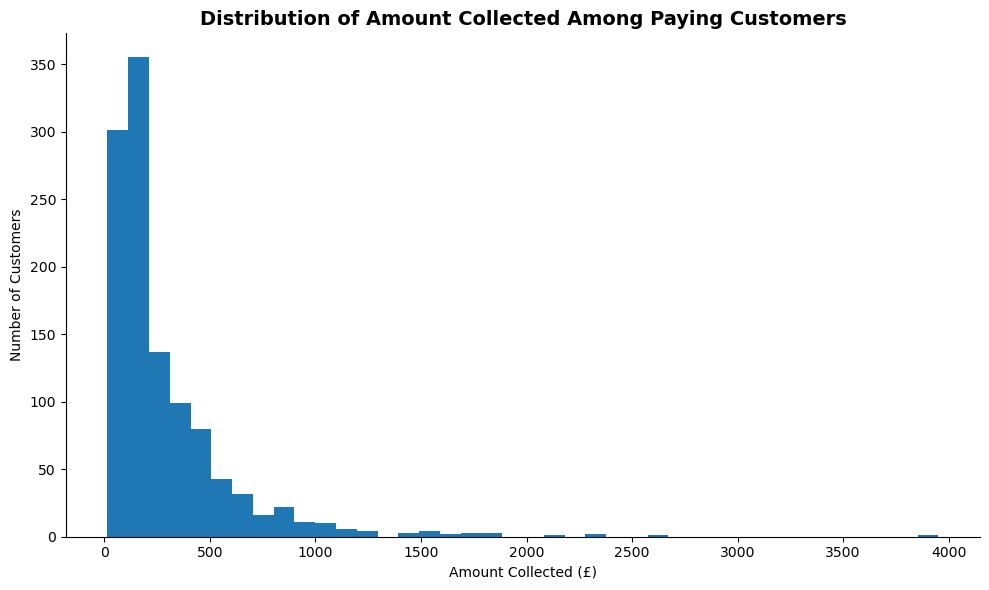

In [38]:
# 3. Plot distribution of amount collected for customers with collection
customers_with_collection = customer_recovery_summary[
    customer_recovery_summary['amount_collected'] > 0
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    customers_with_collection['amount_collected'],
    bins=40
)

ax.set_title('Distribution of Amount Collected Among Paying Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Amount Collected (£)')
ax.set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'amount_collected_distribution_paying_customers.png'), dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# 4. Compare average customer recovery rate by payment and plan status
recovery_status_summary = (
    customer_recovery_summary
    .groupby(['payment_made_flag', 'repayment_plan_created_flag'])
    .agg(
        customers=('customer_id', 'nunique'),
        avg_debt_balance=('debt_balance', 'mean'),
        avg_amount_collected=('amount_collected', 'mean'),
        avg_customer_recovery_rate=('customer_recovery_rate', 'mean')
    )
    .reset_index()
)

# 5. Create readable status labels
recovery_status_summary['customer_status'] = recovery_status_summary.apply(
    lambda row: 'Payment + Plan' if row['payment_made_flag'] == 1 and row['repayment_plan_created_flag'] == 1
    else 'Payment Only' if row['payment_made_flag'] == 1 and row['repayment_plan_created_flag'] == 0
    else 'Plan Only' if row['payment_made_flag'] == 0 and row['repayment_plan_created_flag'] == 1
    else 'No Payment or Plan',
    axis=1
)

recovery_status_summary

,payment_made_flag,repayment_plan_created_flag,customers,avg_debt_balance,avg_amount_collected,avg_customer_recovery_rate,customer_status
0,0,0,8685,"1,029.94",0.00,0.00,No Payment or Plan
1,0,1,179,888.42,0.00,0.00,Plan Only
2,1,0,572,655.93,258.21,0.70,Payment Only
3,1,1,564,917.35,324.86,0.44,Payment + Plan


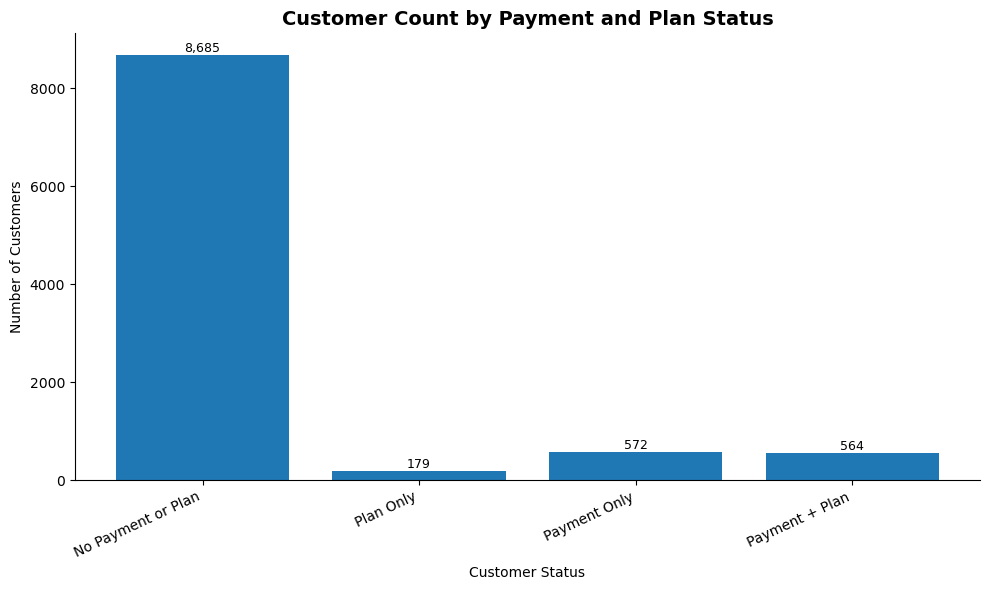

In [41]:
# 6. Plot customer count by payment and plan status
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    recovery_status_summary['customer_status'],
    recovery_status_summary['customers']
)

ax.set_title('Customer Count by Payment and Plan Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Status')
ax.set_ylabel('Number of Customers')

plt.xticks(rotation=25, ha='right')

# 7. Add value labels
for index, value in enumerate(recovery_status_summary['customers']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'customer_count_by_payment_plan_status.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The customer-level recovery view shows that repayment behaviour is not evenly distributed across all accounts. Debt balances vary widely, and many customers have no collected amount, while a smaller group contributes actual payments.

The distribution of amount collected among paying customers helps separate customer participation from payment size. This is important because average collection values can be influenced by a smaller number of customers making larger payments.

The payment and plan status breakdown adds another useful behavioural view. Customers with direct payments represent immediate recovery, while customers with repayment plans represent future recovery potential that depends on plan sustainability. Customers with no payment or plan represent the largest opportunity for further journey optimisation.

This distinction is important because a repayment plan should not be treated the same as collected revenue. A plan only becomes commercially valuable if the customer pays the first instalment and continues making payments.

**Indication:** Customer-level recovery analysis helps DebtStream separate immediate recovery, future repayment potential, and non-converting accounts. This supports more targeted repayment journeys rather than relying only on overall recovery averages.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 11: Final Business Recommendations
</h2>

**Translate Recovery Insights into Repayment Strategy**

This section summarises the final business recommendations from the repayment and recovery analysis.

The goal is to translate segment-level recovery patterns into practical actions for DebtStream's digital collections journey.

## Final Recommendations

**1. Use balance band to guide repayment journey design.**  
Low-balance customers show stronger recovery rates and are better suited to direct payment journeys. Medium-balance customers show stronger repayment plan behaviour and should receive more repayment-plan nudges. High and Very High balance customers need more support-led journeys, especially where broken-plan risk is high.

**2. Prioritise early digital intervention for newer debt.**  
Recovery performance is strongest in newer debt age bands and declines as debt gets older. DebtStream should prioritise fast, clear, and well-timed digital engagement before accounts become harder to recover.

**3. Use affordability assessment as a plan sustainability lever.**  
Customers who complete affordability assessment show better first-instalment success and lower broken-plan rates. Affordability completion should be encouraged before or during repayment plan creation, especially for higher-balance customers.

**4. Benchmark performance by client type.**  
Telecoms and Consumer Lender portfolios show stronger recovery performance, while Legal Collections and Debt Purchaser portfolios show weaker outcomes. DebtStream should avoid using one overall recovery benchmark for all client portfolios.

**5. Prioritise high-exposure, low-recovery segments.**  
The most important optimisation opportunities are not just the segments with the lowest recovery rate, but the segments that combine weak recovery with high outstanding balance exposure.

**6. Track plan sustainability, not just plan setup.**  
A repayment plan should not be treated as a final success metric. Broken-plan rate, first instalment paid rate, missed payments, and affordability completion should be tracked alongside plan setup.

## Final Conclusion

DebtStream's repayment optimisation strategy should combine customer balance, debt age, client type, affordability status, and repayment behaviour.

The strongest commercial opportunity is to move away from a single generic digital collections journey and towards a segmented strategy that matches the repayment journey to customer risk, balance size, debt age, and affordability needs.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 12: Export Confirmation
</h2>

**Export Final Recovery Outputs**

In this final section, I am exporting selected Python-generated recovery outputs.

In [43]:
# ============================================================
# Section 12: Export Final Recovery Outputs
# ============================================================

# 1. Export overall recovery baseline
overall_recovery_baseline.to_csv(
    os.path.join(SUMMARY_TABLES_PATH, 'python_overall_recovery_baseline.csv'),
    index=False
)

# 2. Export high exposure low recovery segments
high_exposure_low_recovery.to_csv(
    os.path.join(SUMMARY_TABLES_PATH, 'python_high_exposure_low_recovery_segments.csv'),
    index=False
)

# 3. Export customer payment and plan status summary
recovery_status_summary.to_csv(
    os.path.join(SUMMARY_TABLES_PATH, 'python_recovery_status_summary.csv'),
    index=False
)

print("Python-generated recovery insight tables exported successfully.")

Python-generated recovery insight tables exported successfully.


In [44]:
# 4. List recovery charts exported from this notebook
recovery_charts = sorted([
    file for file in os.listdir(CHARTS_PATH)
    if (
        file.startswith('recovery_') or
        file.startswith('payment_vs_plan_setup_by') or
        file.startswith('broken_plan_rate_by') or
        file.startswith('first_instalment') or
        file.startswith('avg_missed') or
        file.startswith('top_10_weakest') or
        file.startswith('customer_debt') or
        file.startswith('amount_collected') or
        file.startswith('avg_recovery')
    )
])

recovery_charts

['amount_collected_distribution_paying_customers.png',
 'avg_missed_payments_by_affordability.png',
 'avg_recovery_rate_by_customer_status.png',
 'broken_plan_rate_by_affordability.png',
 'broken_plan_rate_by_balance_band.png',
 'broken_plan_rate_by_client_type.png',
 'broken_plan_rate_by_debt_age_band.png',
 'customer_debt_balance_distribution.png',
 'first_instalment_paid_rate_by_affordability.png',
 'payment_vs_plan_setup_by_balance_band.png',
 'payment_vs_plan_setup_by_balance_band_recovery.png',
 'payment_vs_plan_setup_by_client_type.png',
 'payment_vs_plan_setup_by_debt_age_band.png',
 'recovery_outstanding_vs_collected.png',
 'recovery_rate_by_balance_band.png',
 'recovery_rate_by_client_type.png',
 'recovery_rate_by_debt_age_band.png',
 'recovery_rate_matrix_balance_debt_age.png',
 'top_10_weakest_recovery_segments.png']

In [45]:
# 5. List Python-generated recovery summary tables
recovery_summary_tables = sorted([
    file for file in os.listdir(SUMMARY_TABLES_PATH)
    if file.startswith('python_')
])

recovery_summary_tables

['python_ab_test_amount_ttest_result.csv',
 'python_ab_test_balance_band_plan_tests.csv',
 'python_ab_test_ztest_results.csv',
 'python_high_exposure_low_recovery_segments.csv',
 'python_overall_recovery_baseline.csv',
 'python_recovery_status_summary.csv']

## Notebook 3 Summary

This notebook analysed DebtStream's repayment and recovery outcomes across customer balance bands, debt age bands, client types, affordability status, and recovery priority segments.

The analysis showed that recovery performance is strongest among lower-balance and newer-debt accounts, while higher-balance and older-debt segments show weaker recovery and higher plan-sustainability risk.

Affordability assessment appears to support stronger repayment plan sustainability, with better first-instalment performance and lower broken-plan rates.

This completes the Python analysis phase of the DebtStream project.

The next project phase is to build the final interactive Power BI report.